<a href="https://colab.research.google.com/github/meytriangg/Data-Mining-Course/blob/main/K_Drama_Data_Visualization_Exploring_Trends%2C_Genres%2C_and_Ratings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



>Mey Tri Anggraheni
2304020067



# **K-Drama Data Visualization: Exploring Trends, Genres, and Ratings**

Korean dramas, commonly known as **K-Dramas**, have become one of the most popular forms of entertainment worldwide. Over the past decade, the global popularity of K-Dramas has increased significantly due to engaging storylines, diverse genres, and high production quality. Many streaming platforms and television networks continuously produce new dramas each year, making the industry grow rapidly.

In this project, a K-Drama dataset obtained from Kaggle is analyzed using data visualization techniques to explore patterns and trends in the K-Drama industry. Several visualizations are created to better understand the characteristics of K-Dramas based on ratings, genres, release trends, and other variables.

**The visualizations presented in this analysis include:**
1. Top 10 Highest Rated K-Dramas
2. Trend of K-Drama Releases by Year
3. Most Popular Genre in K-Dramas
4. Correlation Between K-Drama Episode and Rating
5. Relationship Between K-Drama Genres and Rating
6. Correlation Between K-Drama Variables

The dataset include**s K-Dramas released from 2003 to 2022**, providing insights into trends and characteristics of dramas over time.

# **Top 10 Highest Rated K-Dramas**

/tmp/ipykernel_505/3100999041.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(


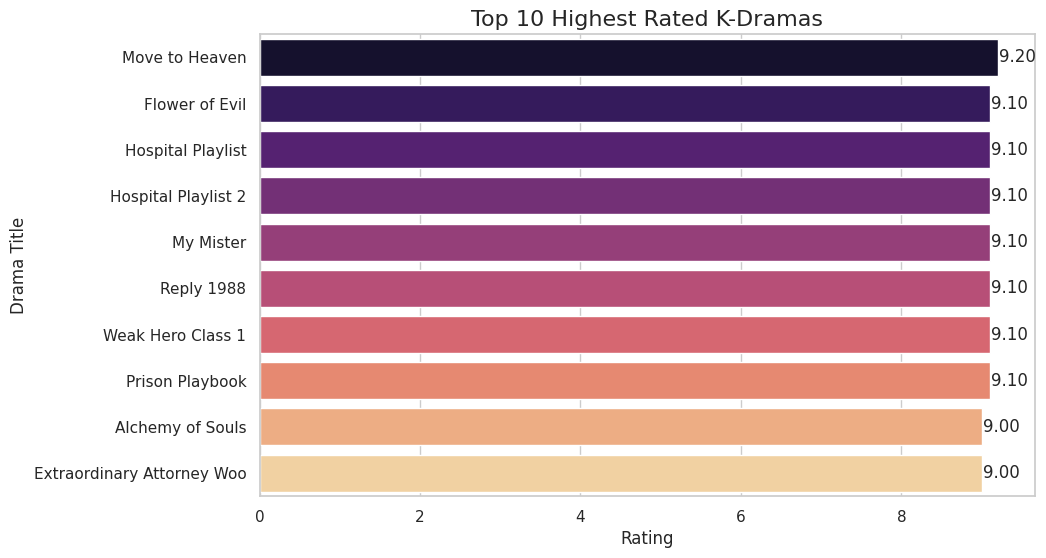

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("kdrama.csv")

sns.set_theme(style="whitegrid")

# ambil top 10 rating tertinggi
top10 = df.sort_values(by="Rating", ascending=False).head(10)

plt.figure(figsize=(10,6))

bar = sns.barplot(
    x="Rating",
    y="Name",
    data=top10,
    palette="magma"
)

# menampilkan nilai rating di samping bar
for i, value in enumerate(top10["Rating"]):
    plt.text(value + 0.02, i, f"{value:.2f}", va='center')

plt.title("Top 10 Highest Rated K-Dramas", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Drama Title")

plt.show()


This chart shows that "Move to Heaven" is the number one drama with a 9.20 rating. Other famous dramas like Flower of Evil and Hospital Playlist are very close behind with a 9.10 rating. It shows that fans really love these stories!

# **Trend of K-Drama Releases by Year**

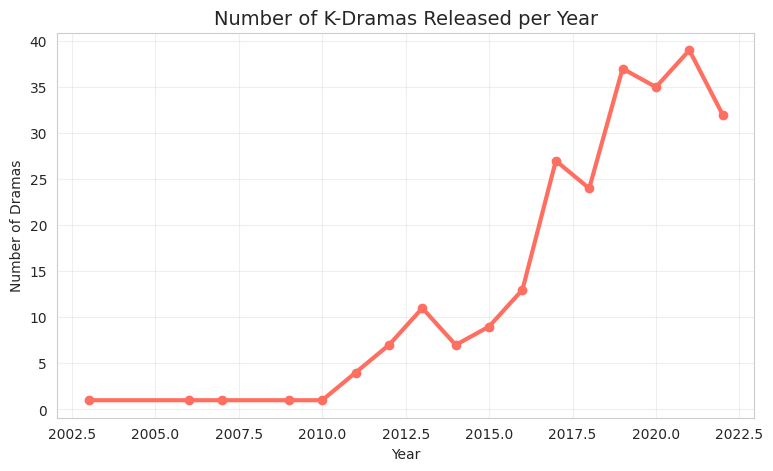

In [11]:
drama_per_year = df["Year of release"].value_counts().sort_index()

plt.figure(figsize=(9,5))
plt.plot(drama_per_year.index, drama_per_year.values,
         marker='o', linewidth=3, color="#FF6F61")

plt.title("Number of K-Dramas Released per Year", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Number of Dramas")

plt.grid(alpha=0.3)
plt.show()

This line graph shows a big jump in how many K-Dramas are made. Before 2010, there were only a few each year. But after 2015, the number went up fast! It reached a peak in 2021 with almost 40 dramas, showing that K-Dramas are becoming more popular every year.

# **Most Popular Genres in K-Dramas**

/tmp/ipykernel_505/1110085267.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genre.values,


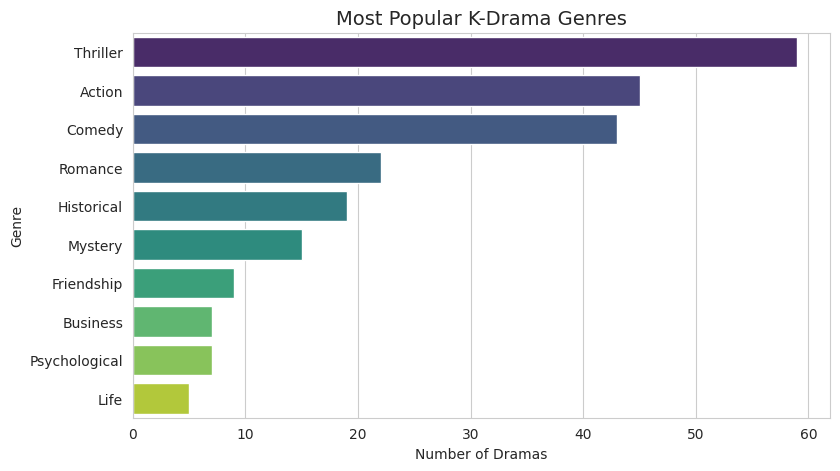

In [12]:
df["Main Genre"] = df["Genre"].str.split(",").str[0]
top_genre = df["Main Genre"].value_counts().head(10)

plt.figure(figsize=(9,5))
sns.barplot(x=top_genre.values,
            y=top_genre.index,
            palette="viridis")

plt.title("Most Popular K-Drama Genres", fontsize=14)
plt.xlabel("Number of Dramas")
plt.ylabel("Genre")

plt.show()

This bar chart tells us which types of stories are made the most. Thriller is the winner with the highest number of dramas. Action and Comedy are also very popular. Even though many people think of romance first, this data shows that people also love exciting and funny shows!

# **Correlation Between Number of Episodes and Rating**

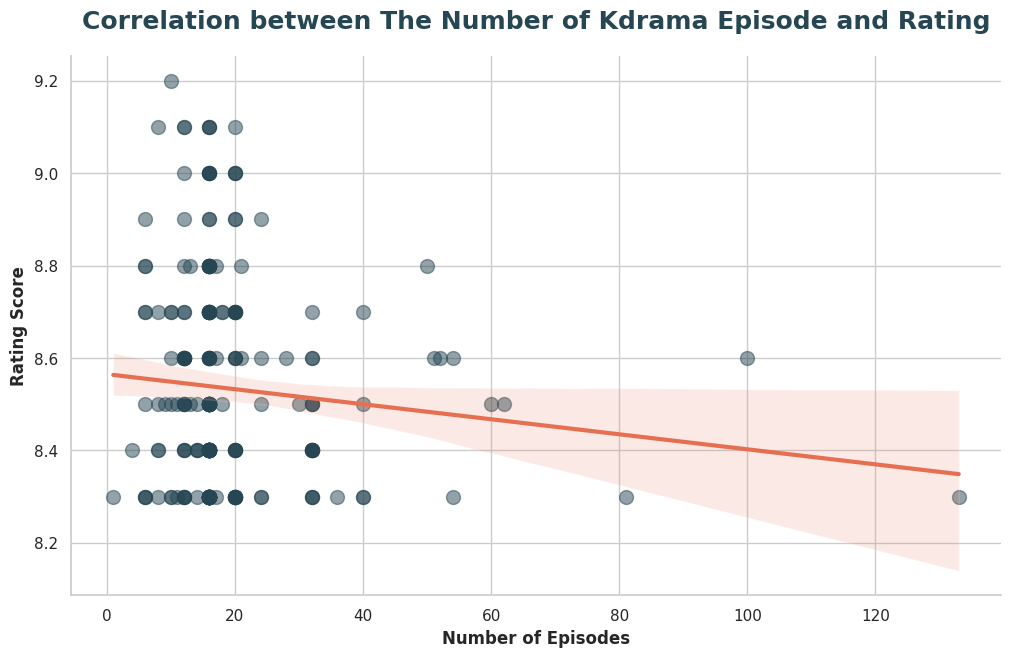

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set tema modern
sns.set_theme(style="whitegrid")

# 2. Ukuran kanvas
plt.figure(figsize=(12, 7))

# 3. Membuat Regression Plot (Scatter Plot + Garis Tren)
# Ini jauh lebih modern karena menunjukkan ke mana arah datanya
sns.regplot(
    data=df,
    x="Number of Episodes",
    y="Rating",
    scatter_kws={'s':100, 'alpha':0.5, 'color':'#264653'}, # Warna gelap untuk titik
    line_kws={'color':'#E76F51', 'lw':3},                # Warna kontras untuk garis tren
    marker='o'
)

# 4. Judul dan Label yang lebih rapi
plt.title("Correlation between The Number of Kdrama Episode and Rating",
          fontsize=18, fontweight='bold', pad=20, color='#264653')
plt.xlabel("Number of Episodes", fontsize=12, fontweight='semibold')
plt.ylabel("Rating Score", fontsize=12, fontweight='semibold')

# 5. Menghilangkan border atas dan kanan agar lebih "clean"
sns.despine()

plt.show()

The chart shows that there is a negative correlation between the number of episodes and viewer ratings. Most of the highest-rated K-Dramas are concentrated in the short-form category, typically between 10 to 20 episodes. As the number of episodes increases, the orange trend line slopes downward, suggesting that longer series often struggle to maintain the same high scores as shorter ones. In simple terms, shorter dramas are much more likely to receive top ratings from fans.

# **Relationship Between K-Drama Genre and Ratings**

/tmp/ipykernel_505/2741851447.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


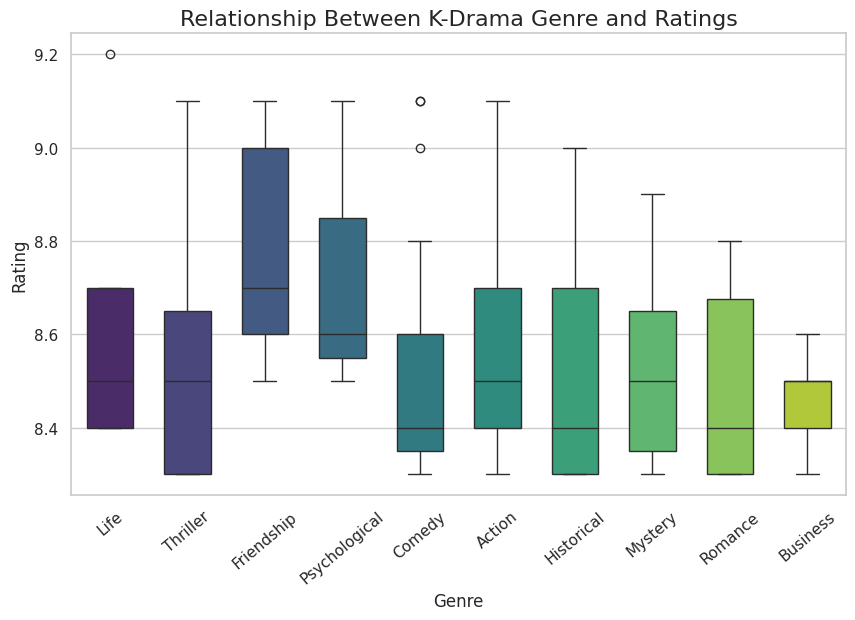

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("kdrama.csv")

# ambil genre utama
df["Main Genre"] = df["Genre"].str.split(",").str[0]

# ambil 10 genre paling sering
top_genres = df["Main Genre"].value_counts().head(10).index
df_top = df[df["Main Genre"].isin(top_genres)]

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(
    x="Main Genre",
    y="Rating",
    data=df_top,
    palette="viridis",
    width=0.6
)

plt.title("Relationship Between K-Drama Genre and Ratings", fontsize=16)
plt.xlabel("Genre")
plt.ylabel("Rating")

plt.xticks(rotation=40)

plt.show()


The chart shows that Friendship and Psychological genres generally have the highest average ratings, as their boxes are positioned higher than the others. While the Thriller and Life genres have a wider range of scores, they both have "star" dramas with very high ratings (the dots at the top). On the other hand, the Business genre tends to have the lowest and most limited ratings

Explanation: The middle line represents the median rating, showing the typical performance of each genre. For example, Friendship has the highest median, making it a very reliable genre. The height of the box represents the consistency of the ratings. A tall box, like in the Thriller genre, shows that ratings vary widely from high to low, while a short box indicates that most dramas in that category have very similar scores.

# **Correlation Between K-Dramas Variables**

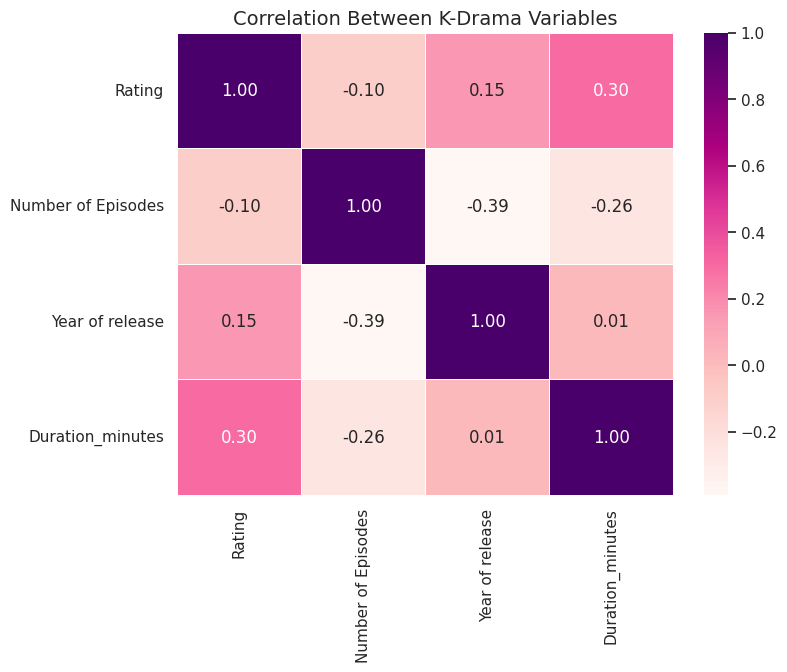

In [29]:
import re

def parse_duration_to_minutes(duration_str):
    if pd.isna(duration_str):  # Handle potential NaN values
        return None

    total_minutes = 0
    # Extract hours and minutes using regex
    hours_match = re.search(r'(\d+)\s*hr\.', duration_str)
    minutes_match = re.search(r'(\d+)\s*min\.', duration_str)

    if hours_match:
        total_minutes += int(hours_match.group(1)) * 60
    if minutes_match:
        total_minutes += int(minutes_match.group(1))

    return total_minutes if total_minutes > 0 else None

# Apply the function to create a new 'Duration_minutes' column
df['Duration_minutes'] = df['Duration'].apply(parse_duration_to_minutes)

# Select numerical variables for correlation, using the new 'Duration_minutes' column
data = df[["Rating", "Number of Episodes", "Year of release", "Duration_minutes"]].dropna()

corr = data.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="RdPu",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Between K-Drama Variables", fontsize=14)

plt.show()

The heatmap shows how different parts of K-Dramas relate to each other. The strongest positive connection is between Rating and Duration (0.30), which means dramas with longer episodes often get slightly better ratings. However, there is a negative correlation (-0.39) between the Year of Release and the Number of Episodes. This tells us that newer dramas tend to have fewer episodes compared to older ones. Most other relationships are weak, meaning things like the year of release don't really change the rating score much.